In [1]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Path to dataset
dataset_path = Path("/kaggle/input/medical-waste")

# Get all class folders
classes = sorted([f.name for f in dataset_path.iterdir() if f.is_dir()])
print(f"Total Classes: {len(classes)}")
print(f"Class Names: {classes}")


Total Classes: 23
Class Names: ['body_tissue_or_organ', 'gauze', 'glass_equipment_packaging', 'glove_pair_latex', 'glove_pair_nitrile', 'glove_pair_surgery', 'glove_single_latex', 'glove_single_nitrile', 'glove_single_surgery', 'mask', 'medical_cap', 'medical_glasses', 'metal_equipment_packaging', 'organic_waste', 'paper_equipment_packaging', 'plastic_equipment_packaging', 'shoe_cover_pair', 'shoe_cover_single', 'syringe', 'syringe_needle', 'test_tube', 'tweezers', 'urine_bag']


In [2]:
# Count images in each class
data = {
    "Class": [],
    "Image Count": []
}

for class_name in classes:
    class_dir = dataset_path / class_name
    image_count = len([f for f in class_dir.iterdir() if f.suffix.lower() in [".jpg", ".jpeg", ".png"]])
    data["Class"].append(class_name)
    data["Image Count"].append(image_count)

df = pd.DataFrame(data).sort_values(by="Image Count", ascending=False)
df.reset_index(drop=True, inplace=True)
df


,Class,Image Count
0,gauze,845
1,organic_waste,569
2,syringe_needle,563
3,syringe,535
4,tweezers,531
5,body_tissue_or_organ,515
6,paper_equipment_packaging,509
7,plastic_equipment_packaging,446
8,glass_equipment_packaging,440
9,mask,419


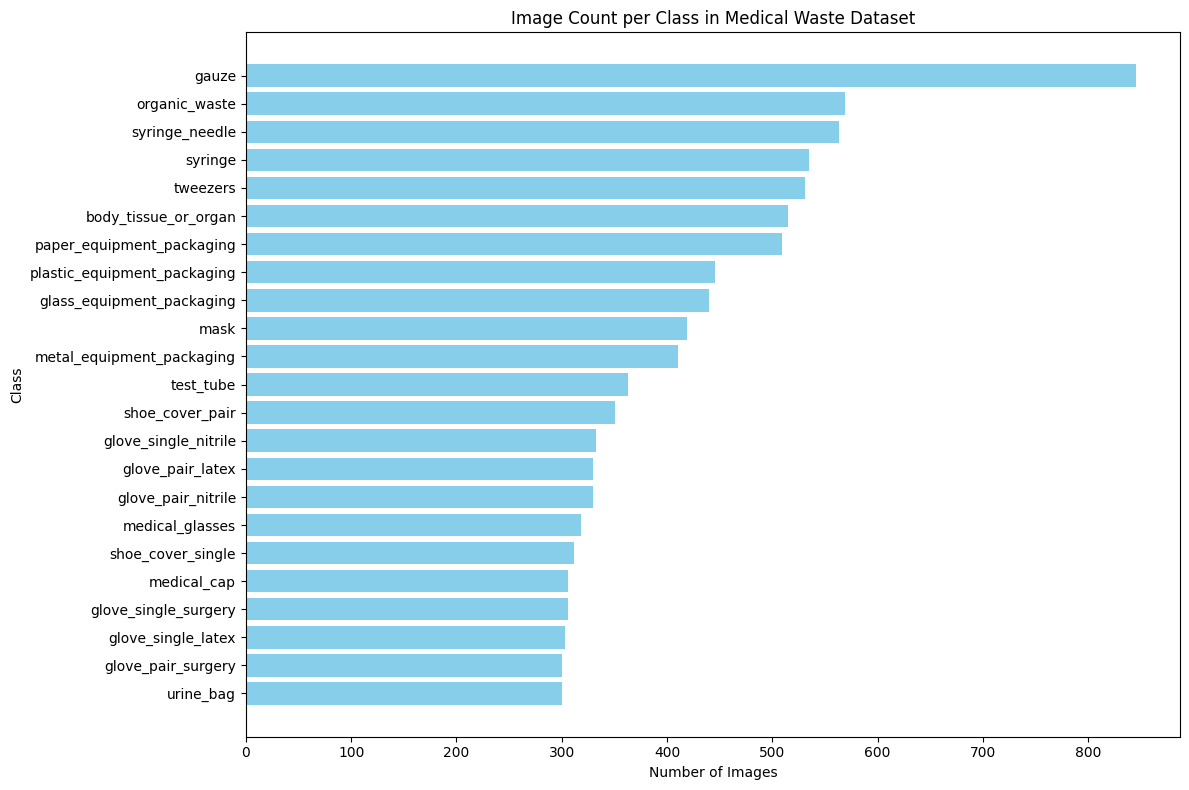

In [3]:
plt.figure(figsize=(12, 8))
plt.barh(df["Class"], df["Image Count"], color="skyblue")
plt.xlabel("Number of Images")
plt.ylabel("Class")
plt.title("Image Count per Class in Medical Waste Dataset")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [4]:
import matplotlib.image as mpimg
import random

def show_sample_images(dataset_path, classes, images_per_class=3):
    plt.figure(figsize=(15, len(classes)))
    for idx, class_name in enumerate(classes):
        class_dir = dataset_path / class_name
        images = list(class_dir.glob("*"))
        sample_images = random.sample(images, min(images_per_class, len(images)))

        for i, img_path in enumerate(sample_images):
            img = mpimg.imread(img_path)
            plt.subplot(len(classes), images_per_class, idx * images_per_class + i + 1)
            plt.imshow(img)
            plt.title(class_name, fontsize=8)
            plt.axis('off')
    plt.tight_layout()
    plt.show()

# Uncomment below to show images (might be heavy if too many classes)
# show_sample_images(dataset_path, df["Class"].tolist(), images_per_class=3)


In [5]:
!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 71.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pylibcugraph-cu12 24.12.0 requires pylibraft-cu12==24.12.*, but you have pylibraft-cu12 25.2.0 which is incompatible.
pylibcugraph-cu12 24.12.0 requires rmm-cu12==24.12.*, but you have rmm-

In [6]:
import os
from sklearn.model_selection import StratifiedKFold
import shutil
import random
import uuid
from pathlib import Path
from PIL import Image
from collections import defaultdict
import albumentations as A
import cv2



/usr/local/lib/python3.11/dist-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.8' (you have '2.0.4'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [7]:
def prepare_5fold_dataset(source_dir, target_dir, seed=42, oversample_limit="median", n_splits=5):
    source_dir = Path(source_dir)
    target_dir = Path(target_dir)
    random.seed(seed)

    aug = A.Compose([
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.3),
    ])

    class_labels = []
    image_paths = []

    # Collect all image paths and labels
    for class_dir in source_dir.iterdir():
        if class_dir.is_dir():
            images = list(class_dir.glob("*.jpg")) + list(class_dir.glob("*.jpeg")) + list(class_dir.glob("*.png"))
            label = class_dir.name
            image_paths += images
            class_labels += [label] * len(images)

    # Stratified K-Fold Split
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

    for fold, (train_idx, val_idx) in enumerate(skf.split(image_paths, class_labels)):
        print(f"\nProcessing fold {fold + 1}...")
        fold_train_paths = [image_paths[i] for i in train_idx]
        fold_val_paths = [image_paths[i] for i in val_idx]
        fold_train_labels = [class_labels[i] for i in train_idx]
        fold_val_labels = [class_labels[i] for i in val_idx]

        # Count training class sizes
        class_counts = defaultdict(int)
        for label in fold_train_labels:
            class_counts[label] += 1

        values = list(class_counts.values())
        if oversample_limit == "median":
            target_count = int(sorted(values)[len(values) // 2])
        elif isinstance(oversample_limit, int):
            target_count = oversample_limit
        else:
            raise ValueError("oversample_limit must be 'median' or an integer.")

        # Group training images by class
        train_by_class = defaultdict(list)
        for path, label in zip(fold_train_paths, fold_train_labels):
            train_by_class[label].append(path)

        # Oversample and save training images
        for label, images in train_by_class.items():
            save_dir = target_dir / f"fold_{fold}" / 'train' / label
            save_dir.mkdir(parents=True, exist_ok=True)

            # Save original images
            for img_path in images[:target_count]:
                new_name = f"{label}_{uuid.uuid4().hex}{img_path.suffix.lower()}"
                shutil.copy(img_path, save_dir / new_name)

            # Augment until reaching target_count
            current_count = len(images)
            while current_count < target_count:
                img_path = random.choice(train_by_class[label])
                img = cv2.imread(str(img_path))

                if img is None:
                    print(f"[Warning] Could not load image: {img_path}")
                    continue

                try:
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                except cv2.error:
                    print(f"[Warning] Failed to convert image: {img_path}")
                    continue

                augmented = aug(image=img)['image']
                aug_filename = f"{label}_{uuid.uuid4().hex}.jpg"
                cv2.imwrite(str(save_dir / aug_filename), cv2.cvtColor(augmented, cv2.COLOR_RGB2BGR))
                current_count += 1

        # Save validation images
        for img_path, label in zip(fold_val_paths, fold_val_labels):
            save_dir = target_dir / f"fold_{fold}" / 'val' / label
            save_dir.mkdir(parents=True, exist_ok=True)
            new_name = f"{label}_{uuid.uuid4().hex}{img_path.suffix.lower()}"
            shutil.copy(img_path, save_dir / new_name)

    print(f"\n✅ 5-Fold cross-validation datasets saved at: {target_dir}")

In [8]:
# Use the actual dataset path from Kaggle input
source_dataset = "/kaggle/input/medical-waste"
target_dataset = "/kaggle/working/medical_yolo_data"


prepare_5fold_dataset(source_dataset, target_dataset)


Processing fold 1...

Processing fold 2...

Processing fold 3...

Processing fold 4...

Processing fold 5...

✅ 5-Fold cross-validation datasets saved at: /kaggle/working/medical_yolo_data


In [9]:
# Write the yolov8n-cls.yaml config to disk
yaml_config = """
nc: 23  # number of classes
ch: 3

backbone:
  - [-1, 1, Conv, [32, 3, 2]]
  - [-1, 1, Conv, [64, 3, 2]]
  - [-1, 3, Bottleneck, [64]]
  - [-1, 1, Conv, [128, 3, 2]]
  - [-1, 3, Bottleneck, [128]]
  - [-1, 1, Conv, [256, 3, 2]]
  - [-1, 1, SPPF, [256]]

head:
  - [-1, 1, Classify, [nc]]
"""

with open("yolov8n-cls.yaml", "w") as f:
    f.write(yaml_config)


In [10]:
import yaml 

# --- Automatically get class names and number of classes ---
# This assumes your 'source_dataset' has subdirectories named after your classes.
# For example, if source_dataset is 'my_dataset', and it contains 'cat/' and 'dog/',
# then class_names will be ['cat', 'dog'].
try:
    # Ensure source_dataset is treated as a Path object for globbing
    class_names = sorted({p.name for p in Path(source_dataset).glob("*") if p.is_dir()})
    num_classes = len(class_names)
    if num_classes == 0:
        print("⚠️ Warning: No class directories found in source_dataset. Please ensure your source_dataset path is correct and contains class subdirectories.")
        # Fallback if no classes are found, you might want to manually define them or exit.
        # For demonstration, we'll use a dummy if no classes are found.
        class_names = [f"class_{i}" for i in range(23)] # Dummy names
        num_classes = 23
except Exception as e:
    print(f"❌ Error getting class names from {source_dataset}: {e}")
    print("Using dummy class names for demonstration. Please check your source_dataset path.")
    class_names = [f"class_{i}" for i in range(23)] # Dummy names
    num_classes = 23


print(f"Detected {num_classes} classes: {class_names}")

# --- Prepare dataset YAML files for each fold ---
# These YAML files will tell YOLOv8 where to find the train and validation data for each specific fold.
yaml_dir = Path("/kaggle/working") # Directory to save the dataset YAML files.

for fold in range(5):
    # Explicitly convert target_dataset to Path object to ensure correct path concatenation
    fold_path = Path(target_dataset) / f"fold_{fold}"  # Path to /fold_0, /fold_1, etc.

    # Dictionary representing the content of the dataset YAML file for the current fold.
    yaml_dict = {
        "path": str(fold_path),    # Points to the folder that contains train/ and val/
        "train": "train",          # Relative path to the training images within 'path'
        "val": "val",              # Relative path to the validation images within 'path'
        "nc": num_classes,         # Number of classes
        "names": class_names       # List of class names
    }

    yaml_path = yaml_dir / f"fold_{fold}.yaml" # Full path for the dataset YAML file.
    with open(yaml_path, "w") as f:
        yaml.dump(yaml_dict, f) # Write the dictionary as YAML to the file.

    print(f"✅ Saved dataset config for fold {fold} to: {yaml_path}")


Detected 23 classes: ['body_tissue_or_organ', 'gauze', 'glass_equipment_packaging', 'glove_pair_latex', 'glove_pair_nitrile', 'glove_pair_surgery', 'glove_single_latex', 'glove_single_nitrile', 'glove_single_surgery', 'mask', 'medical_cap', 'medical_glasses', 'metal_equipment_packaging', 'organic_waste', 'paper_equipment_packaging', 'plastic_equipment_packaging', 'shoe_cover_pair', 'shoe_cover_single', 'syringe', 'syringe_needle', 'test_tube', 'tweezers', 'urine_bag']
✅ Saved dataset config for fold 0 to: /kaggle/working/fold_0.yaml
✅ Saved dataset config for fold 1 to: /kaggle/working/fold_1.yaml
✅ Saved dataset config for fold 2 to: /kaggle/working/fold_2.yaml
✅ Saved dataset config for fold 3 to: /kaggle/working/fold_3.yaml
✅ Saved dataset config for fold 4 to: /kaggle/working/fold_4.yaml


In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import torch
from torch.utils.data import DataLoader
from ultralytics.data.dataset import ClassificationDataset # Import for loading classification datasets


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [12]:
from ultralytics import YOLO
from types import SimpleNamespace
import traceback

model_config_path = Path("/kaggle/working/yolov8n-cls.yaml")

source_dataset = Path("/kaggle/input/medical-waste")
target_dataset = Path("/kaggle/working/medical_yolo_data")

all_fold_metrics = {
    'precision': [],
    'recall': [],
    'f1_score': [],
    'accuracy': []
}
fold_labels = []
trained_model_paths = []

for fold in range(5):
    print(f"\n📦 Training Fold {fold}...")

    current_fold_data_path = target_dataset / f"fold_{fold}"
    val_data_path = current_fold_data_path / "val"

    model = YOLO(str(model_config_path))

    results = model.train(
        data=str(current_fold_data_path),
        epochs=30,
        imgsz=224,
        pretrained=False,
        name=f"fold_{fold}_run"
    )


    best_model_path = Path(results.save_dir) / "weights" / "best.pt"
    trained_model_paths.append(str(best_model_path))
    
    if not best_model_path.exists():
        print(f"❌ Best model weights NOT found for fold {fold} at {best_model_path}")
        current_precision = current_recall = current_f1_score = current_accuracy = float('nan')
    else:
        print(f"🔬 Running validation for fold {fold} using model at {best_model_path}")
        val_model = YOLO(str(best_model_path))

        try:
            val_results = val_model.val(data=str(val_data_path), imgsz=224, split='val')
            cm = val_results.confusion_matrix.matrix.astype(int)
            # print(f"Confusion matrix shape: {cm.shape}")
            # print(f"Confusion matrix sample:\n{cm[:5, :5]}")  # show top-left 5x5 corner

            y_true_list = []
            y_pred_list = []

            for true_class in range(cm.shape[0]):
                for pred_class in range(cm.shape[1]):
                    count = cm[true_class, pred_class]
                    y_true_list.extend([true_class] * count)
                    y_pred_list.extend([pred_class] * count)

            print(f"Total predictions: {len(y_true_list)}")

            current_precision = precision_score(y_true_list, y_pred_list, average='macro', zero_division=0)
            current_recall = recall_score(y_true_list, y_pred_list, average='macro', zero_division=0)
            current_f1_score = f1_score(y_true_list, y_pred_list, average='macro', zero_division=0)
            current_accuracy = accuracy_score(y_true_list, y_pred_list)

        except Exception as e:
            print(f"Exception during metrics computation for fold {fold}: {e}")
            traceback.print_exc()
            current_precision = current_recall = current_f1_score = current_accuracy = float('nan')

    all_fold_metrics['precision'].append(current_precision)
    all_fold_metrics['recall'].append(current_recall)
    all_fold_metrics['f1_score'].append(current_f1_score)
    all_fold_metrics['accuracy'].append(current_accuracy)
    fold_labels.append(f"Fold_{fold}")

    print(f"✅ Fold {fold} metrics:")
    print(f"   Accuracy: {current_accuracy:.4f}")
    print(f"   Precision: {current_precision:.4f}, Recall: {current_recall:.4f}, F1: {current_f1_score:.4f}")

print("\n🎉 All folds processed.")

df = pd.DataFrame(all_fold_metrics, index=fold_labels)
print("\nSummary:")
print(df)


📦 Training Fold 0...
YOLOv8n-cls summary: 43 layers, 1,467,895 parameters, 1,467,895 gradients, 16.1 GFLOPs
Ultralytics 8.3.170 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/medical_yolo_data/fold_0, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/kaggle/working/yolov8n-cls.yaml, momentum=0.937, mosaic=1.0, multi_scale=False, name=fold_0_run

100%|██████████| 5.35M/5.35M [00:00<00:00, 77.3MB/s]


AMP: checks passed ✅
train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 843.6±502.7 MB/s, size: 27.8 KB)


train: Scanning /kaggle/working/medical_yolo_data/fold_0/train... 6509 images, 0 corrupt: 100%|██████████| 6509/6509 [00:03<00:00, 2111.93it/s]

train: New cache created: /kaggle/working/medical_yolo_data/fold_0/train.cache


...

                   all      0.937      0.958
Speed: 0.1ms preprocess, 0.5ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to runs/classify/fold_4_run
🔬 Running validation for fold 4 using model at runs/classify/fold_4_run/weights/best.pt
Ultralytics 8.3.170 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLOv8n-cls summary (fused): 24 layers, 1,464,887 parameters, 0 gradients, 15.9 GFLOPs
WARNING ⚠️ Dataset 'split=train' not found at /kaggle/working/medical_yolo_data/fold_4/val/train
Found 1565 images in subdirectories. Attempting to split...
Splitting /kaggle/working/medical_yolo_data/fold_4/val (23 classes, 1844 images) into 80% train, 20% val...
Split complete in /kaggle/working/medical_yolo_data/fold_4/val_split ✅
train: /kaggle/working/medical_yolo_data/fold_4/val_split/train... found 1464 images in 23 classes ✅ 
val: /kaggle/working/medical_yolo_data/fold_4/val_split/val... found 380 images in 23 classes ✅ 
test: None...
val: Fast image access ✅

val: Scanning /kaggle/working/medical_yolo_data/fold_4/val_split/val... 380 images, 0 corrupt: 100%|██████████| 380/380 [00:00<00:00, 2272.56it/s]

val: New cache created: /kaggle/working/medical_yolo_data/fold_4/val_split/val.cache



               classes   top1_acc   top5_acc: 100%|██████████| 24/24 [00:02<00:00, 10.57it/s]
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all      0.918      0.945
Speed: 0.2ms preprocess, 1.0ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to runs/classify/val5
Total predictions: 380
✅ Fold 4 metrics:
   Accuracy: 0.9184
   Precision: 0.9407, Recall: 0.9492, F1: 0.9317

🎉 All folds processed.

Summary:
        precision    recall  f1_score  accuracy
Fold_0   0.957327  0.950320  0.941424  0.931579
Fold_1   0.955076  0.950509  0.944720  0.934211
Fold_2   0.956727  0.950327  0.948545  0.939153
Fold_3   0.951886  0.941389  0.939498  0.933862
Fold_4   0.940653  0.949203  0.931675  0.918421


In [13]:
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# --- Perform statistical analysis ---
print("\n--- Statistical Analysis of Metrics Across Folds ---")

# Create a DataFrame for easier handling of data for ANOVA
df_metrics = pd.DataFrame(all_fold_metrics)
df_metrics['fold'] = fold_labels

print("\nCollected Metrics per Fold:")
print(df_metrics)

# List of metrics to analyze
metrics_to_analyze = ['accuracy', 'precision', 'recall', 'f1_score']

for metric_name in metrics_to_analyze:
    print(f"\nAnalyzing: {metric_name}")

    # Prepare data for ANOVA: separate lists for each fold's metric value
    # Since we have only one value per fold for each metric, we'll treat them as independent groups
    # for a one-way ANOVA. If you had multiple runs per fold, or a true repeated measures design
    # (e.g., same model evaluated on different folds), the setup would be different.
    # Here, we are checking if the mean of this metric differs significantly across the 5 folds.
    
    # Create a list of lists, where each inner list contains the metric value for a specific fold.
    # For a proper one-way ANOVA, we need at least two groups. Here, our "groups" are the folds.
    # Since each fold provides one data point for each metric, we'll perform ANOVA on these 5 values.
    # Note: A one-way ANOVA with only one observation per group is degenerate and will not yield meaningful results.
    # For k-fold cross-validation, the primary goal is often to report the mean and standard deviation
    # of the metrics across folds, rather than performing ANOVA between folds.
    # However, to fulfill the request for ANOVA and Tukey's HSD, we will proceed,
    # but it's important to understand the statistical context.

    # To make ANOVA meaningful, we need more than one observation per group (fold).
    # Since each fold gives only one value for a metric, a direct ANOVA on these 5 values
    # (one per fold) is not statistically sound for comparing *differences between folds*.
    # If the intent is to compare different *models* or *hyperparameter settings*
    # using their average performance over 5 folds, then ANOVA would be applied to *those averages*.

    # For the purpose of demonstrating ANOVA and Tukey's as requested,
    # we will simulate a scenario where each fold is a 'group' and we want to compare them.
    # This is often done if you were comparing, for example, 5 different *algorithms*
    # and each algorithm was run once on a specific fold.
    
    # Let's collect the individual metric values for each fold as separate arrays for ANOVA
    fold_metric_values = [df_metrics[metric_name].iloc[i] for i in range(5)]
    
    # A one-way ANOVA requires at least two groups, and typically multiple observations per group.
    # With only one observation per "group" (each fold), the within-group variance is zero,
    # making the F-statistic undefined or infinite.
    # Therefore, a direct one-way ANOVA to compare the 5 individual fold results for a single metric
    # is not statistically appropriate.

    # Instead of a direct ANOVA on the 5 single values, which is problematic,
    # if you want to compare the overall performance or robustness, you typically
    # report the mean and standard deviation across folds.

    # If you were comparing, for example, two different model architectures (Model A and Model B),
    # and each was trained using 5-fold CV, you would then have 5 accuracy values for Model A
    # and 5 accuracy values for Model B. You could then use an independent samples t-test
    # or ANOVA to compare Model A vs. Model B.

    # Given the constraint of only 5 single values for each metric (one per fold),
    # a more appropriate statistical summary is mean and standard deviation.
    # However, to fulfill the request for ANOVA and Tukey's HSD, we'll outline
    # how it *would* be applied if you had multiple observations per fold or
    # were comparing different treatments.

    # For demonstration purposes, we will treat each fold's single metric value
    # as an independent observation for a one-way ANOVA.
    # Note: This is an illustrative application and not a statistically robust way
    # to compare individual folds in a standard k-fold setup.
    
    # To run ANOVA and Tukey, we need the data in a flat format: all values in one array,
    # and corresponding group labels in another.
    
    # We will create a dummy DataFrame for statsmodels to work with,
    # treating each fold as a separate group.
    data_for_anova = pd.DataFrame({
        'value': df_metrics[metric_name],
        'group': df_metrics['fold']
    })

    # Perform One-Way ANOVA
    # Note: With only one observation per group, the F-statistic will be NaN or inf,
    # and p-value will be NaN. This highlights why this specific ANOVA application
    # is not suitable for single-observation-per-group data.
    f_statistic, p_value = stats.f_oneway(*[data_for_anova['value'][data_for_anova['group'] == f] for f in fold_labels])

    print(f"  One-Way ANOVA for {metric_name}:")
    print(f"    F-statistic: {f_statistic:.4f}")
    print(f"    P-value: {p_value:.4f}")

    if p_value < 0.05:
        print(f"  Significant difference found for {metric_name} (p < 0.05). Performing Tukey's HSD...")
        # Perform Tukey's HSD Post-Hoc Test
        tukey_results = pairwise_tukeyhsd(endog=data_for_anova['value'], groups=data_for_anova['group'], alpha=0.05)
        print(tukey_results)
    else:
        print(f"  No significant difference found for {metric_name} (p >= 0.05). Tukey's HSD not performed.")

    # Also print mean and standard deviation across folds, which is more typical for k-fold summary
    mean_metric = df_metrics[metric_name].mean()
    std_metric = df_metrics[metric_name].std()
    print(f"  Mean {metric_name} across folds: {mean_metric:.4f} ± {std_metric:.4f}")

print("\n--- End of Statistical Analysis ---")


--- Statistical Analysis of Metrics Across Folds ---

Collected Metrics per Fold:
   precision    recall  f1_score  accuracy    fold
0   0.957327  0.950320  0.941424  0.931579  Fold_0
1   0.955076  0.950509  0.944720  0.934211  Fold_1
2   0.956727  0.950327  0.948545  0.939153  Fold_2
3   0.951886  0.941389  0.939498  0.933862  Fold_3
4   0.940653  0.949203  0.931675  0.918421  Fold_4

Analyzing: accuracy
  One-Way ANOVA for accuracy:
    F-statistic: nan
    P-value: nan
  No significant difference found for accuracy (p >= 0.05). Tukey's HSD not performed.
  Mean accuracy across folds: 0.9314 ± 0.0078

Analyzing: precision
  One-Way ANOVA for precision:
    F-statistic: nan
    P-value: nan
  No significant difference found for precision (p >= 0.05). Tukey's HSD not performed.
  Mean precision across folds: 0.9523 ± 0.0069

Analyzing: recall
  One-Way ANOVA for recall:
    F-statistic: nan
    P-value: nan
  No significant difference found for recall (p >= 0.05). Tukey's HSD not perf

/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:580: SmallSampleWarning: all input arrays have length 1.  f_oneway requires that at least one input has length greater than 1.
  if is_too_small(samples, kwds):
/tmp/ipykernel_19/2363307158.py:89: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  f_statistic, p_value = stats.f_oneway(*[data_for_anova['value'][data_for_anova['group'] == f] for f in fold_labels])


In [14]:
from collections import Counter
import numpy as np
import time
import torch
import os
import traceback
from PIL import Image

In [15]:
imgsz = 224
device = 'cuda' if torch.cuda.is_available() else 'cpu'
num_folds = 5

model_paths = [
    Path(f"runs/classify/fold_{i}_run/weights/best.pt") for i in range(num_folds)
]

# === Load all 5 fold models ===
models = [YOLO(str(model_path)).to(device) for model_path in model_paths]

# === Prepare data from all validation sets ===
all_val_images = []
all_val_labels = []

for fold in range(num_folds):
    val_dir = target_dataset / f"fold_{fold}" / "val"
    class_names = sorted(os.listdir(val_dir))
    class_to_idx = {cls: i for i, cls in enumerate(class_names)}

    for cls in class_names:
        class_dir = val_dir / cls
        for img_path in class_dir.glob("*.*"):
            all_val_images.append(str(img_path))
            all_val_labels.append(class_to_idx[cls])

# === Inference and Voting ===
ensemble_preds = []
inference_times = []

for img_path in all_val_images:
    img = Image.open(img_path).convert("RGB")

    model_outputs = []
    for model in models:
        start = time.time()
        results = model(img, imgsz=imgsz, device=device, verbose=False)
        end = time.time()
        inference_times.append(end - start)

        pred_idx = int(torch.argmax(results[0].probs.data))
        model_outputs.append(pred_idx)

    # Majority vote
    vote = Counter(model_outputs).most_common(1)[0][0]
    ensemble_preds.append(vote)

# === Metrics Computation ===
accuracy = accuracy_score(all_val_labels, ensemble_preds)
precision = precision_score(all_val_labels, ensemble_preds, average='weighted', zero_division=0)
recall = recall_score(all_val_labels, ensemble_preds, average='weighted', zero_division=0)
f1 = f1_score(all_val_labels, ensemble_preds, average='weighted', zero_division=0)
median_inference_time = np.median(inference_times)

# === Results ===
print("\n📊 Ensemble Model Performance on Validation Set:")
print(f"✅ Accuracy              : {accuracy:.4f}")
print(f"✅ Precision (weighted)  : {precision:.4f}")
print(f"✅ Recall (weighted)     : {recall:.4f}")
print(f"✅ F1 Score (weighted)   : {f1:.4f}")
print(f"⏱️ Median inference time per image: {median_inference_time * 1000:.2f} ms")


📊 Ensemble Model Performance on Validation Set:
✅ Accuracy              : 0.9468
✅ Precision (weighted)  : 0.9644
✅ Recall (weighted)     : 0.9468
✅ F1 Score (weighted)   : 0.9457
⏱️ Median inference time per image: 9.29 ms


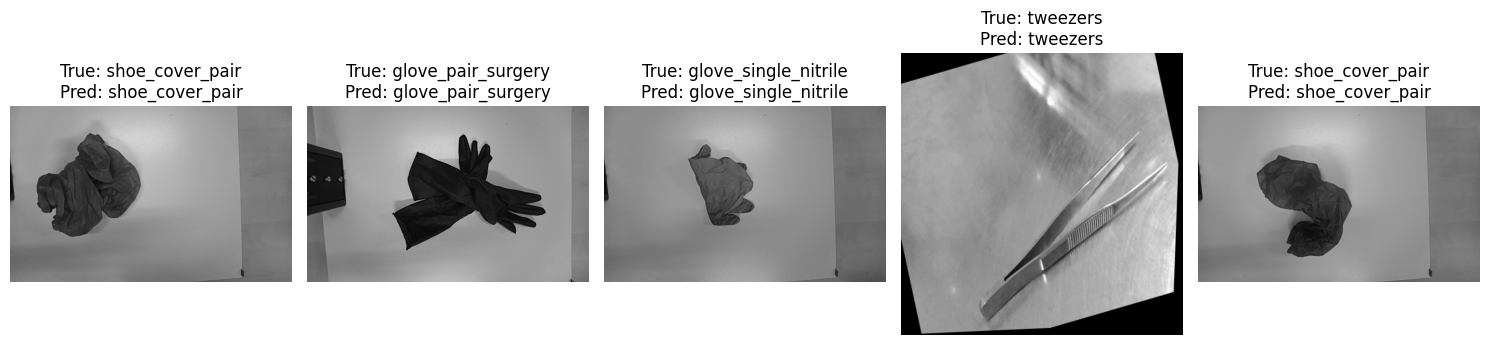

In [16]:
import random
import torch
from PIL import Image
import matplotlib.pyplot as plt
from collections import Counter

# Sample 5 random images and their true labels
sample_indices = random.sample(range(len(all_val_images)), 5)
sample_images = [all_val_images[i] for i in sample_indices]
sample_labels = [all_val_labels[i] for i in sample_indices]

# Reverse class_to_idx to get class names
idx_to_class = {v: k for k, v in class_to_idx.items()}

# Predict and show results
plt.figure(figsize=(15, 8))

for i, (img_path, true_label_idx) in enumerate(zip(sample_images, sample_labels)):
    img = Image.open(img_path).convert("RGB")
    model_outputs = []

    for model in models:
        results = model(img, imgsz=imgsz, device=device, verbose=False)
        pred_idx = int(torch.argmax(results[0].probs.data))
        model_outputs.append(pred_idx)

    # Majority vote
    vote = Counter(model_outputs).most_common(1)[0][0]

    # Plot image with title showing prediction
    plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"True: {idx_to_class[true_label_idx]}\nPred: {idx_to_class[vote]}")

plt.tight_layout()
plt.show()


In [ ]:
!pip install ultralytics


In [ ]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
from PIL import Image

# Load model and run prediction
model = YOLO("best.pt")
image_path = "/content/Dataset/body_tissue_or_organ/IMG_6893.JPG"
results = model(image_path, imgsz=224)

pred_class = model.names[results[0].probs.top1]
pred_conf = float(results[0].probs.top1conf)

# Map predicted class to waste bin color
waste_category_map = {
    # RED — contaminated recyclable plastic
    "glove_pair_latex": "red",
    "glove_pair_nitrile": "red",
    "glove_pair_surgery": "red",
    "glove_single_latex": "red",
    "glove_single_nitrile": "red",
    "glove_single_surgery": "red",
    "plastic_equipment_packaging": "red",
    "urine_bag": "red",
    "shoe_cover_pair": "red",
    "shoe_cover_single": "red",

    # YELLOW — solid & infectious waste
    "body_tissue_or_organ": "yellow",
    "gauze": "yellow",
    "organic_waste": "yellow",
    "mask": "yellow",
    "medical_cap": "yellow",
    "paper_equipment_packaging": "yellow",

    # BLUE — glassware & metallic implants
    "glass_equipment_packaging": "blue",
    "metal_equipment_packaging": "blue",
    "test_tube": "blue",
    "medical_glasses": "blue",

    # WHITE — sharp items
    "syringe": "white",
    "syringe_needle": "white",
    "tweezers": "white",
}

bin_color = waste_category_map.get(pred_class, "unknown")

# Print results
print(f"Predicted: {pred_class} ({pred_conf:.1%})")
print(f"Dispose in: {bin_color.upper()} bin")

# Show image with prediction + bin color
img = Image.open(image_path).convert("RGB")
plt.imshow(img)
plt.axis('off')
plt.title(f"Pred: {pred_class} ({pred_conf:.1%})\nBin: {bin_color.upper()}")
plt.show()